# <center>**Tecnológico de Costa Rica**</center>

***IC-6200 / Inteligencia artificial***

Profesor

*   **Efren Jimenez Delgado**

Proyecto JarvisTEC, I Semestre 2026

## Análisis del Problema

La infección crónica por el virus de la hepatitis C puede evolucionar de una hepatitis a fibrosis y a cirrosis, y la etapa se estima con análisis de sangre y otras pruebas (Manns et al., 2017). Queremos clasificar el estado hepático de una persona en cuatro clases ordenadas: **donante** (sano), **hepatitis**, **fibrosis** y **cirrosis**, a partir de su edad y de diez análisis de laboratorio.

Es un problema de **clasificación multiclase supervisada muy desbalanceada**: cerca del 88 % son donantes y cada clase de enfermedad tiene entre 21 y 30 casos.

**Es un ejercicio educativo con un conjunto de datos pequeño. No es una herramienta de diagnóstico ni reemplaza a un profesional de la salud.**

# Caso Aplicado: Estado Hepático por Hepatitis C
## Clasificación multiclase con clases muy raras, datos faltantes y poblaciones distintas

---

**Temas:** Clases raras · Valores faltantes: artefacto o señal · Validación cruzada estratificada · Intervalos bootstrap  
**Herramientas:** Python · Pandas · Scikit-learn · Seaborn

---

### El hilo conductor

| Etapa | Pregunta central |
|---|---|
| 1 — Entendimiento y limpieza | ¿Qué clases hay, cuáles son ambiguas y qué dicen los valores faltantes? |
| 2 — Exploración | ¿Qué análisis cambian con la gravedad de la enfermedad? |
| 3 — Modelo | ¿Qué clasificador rinde mejor con tan pocos casos de cada enfermedad? |
| 4 — Evaluación | ¿Qué tan estable es el resultado y qué clases se detectan mal? |

> Nota: con 4 a 6 casos por clase en la prueba, el resultado depende mucho de qué personas cayeron ahí. Hay que mirar las predicciones fuera de muestra y los intervalos, no solo un número.

Este notebook es un extra del modelo 06 del proyecto: reproduce de forma didáctica el entrenamiento que hace `train.py` y se puede probar en Google Colab. No reemplaza al código del repositorio.

### Autores

   * Equipo JarvisTEC (proyecto de la primera etapa)

### Librerías

In [1]:
# Manejo de datasets
import pandas as pd
import numpy as np
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Modelos
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_predict, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Ignorar Warnings
import warnings
warnings.filterwarnings('ignore')

SEMILLA = 42

---
# Sección 1: Entendimiento de los Datos
---

## Entendimiento de los Datos

El conjunto reúne datos de laboratorio de donantes de sangre y de pacientes con hepatitis C (Lichtinghagen et al., 2013; Hoffmann et al., 2018). Tiene 615 personas y estas columnas:

- Category : variable objetivo, la clase (donante, "suspect Blood Donor", hepatitis, fibrosis o cirrosis)
- Age, Sex : edad y sexo
- ALB, ALP, ALT, AST, BIL, CHE, CHOL, CREA, GGT, PROT : diez análisis de laboratorio, todas variables cuantitativas
- La primera columna sin nombre es un índice y se descarta

Los datos están en el archivo `dataset.csv` de la carpeta `backend/features/modelo_06_hepatitis/` del repositorio. Son 615 filas y 14 columnas.

En Colab hay dos formas de usarlo: arrastrarlo al panel de archivos (queda en `sample_data/`) o subirlo cuando la celda lo pida.

In [2]:
# Ubicar el archivo de datos (Colab o ejecución local)
import os

RUTA = next((r for r in ("sample_data/dataset.csv", "dataset.csv") if os.path.exists(r)), None)
if RUTA is None:
    try:
        from google.colab import files
        print("Seleccione el archivo dataset.csv")
        RUTA = next(iter(files.upload()))
    except ImportError:
        raise FileNotFoundError("No se encontró dataset.csv: colóquelo en sample_data/ o en la carpeta actual")
print("Archivo de datos:", RUTA)

Archivo de datos: sample_data/dataset.csv


In [3]:
# Cargar los datos
datos = pd.read_csv(RUTA)
datos.head()

,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [4]:
# Información del dataset
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    object 
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    object 
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 67.4+ KB


### Limpieza

Siete personas tienen la categoría "suspect Blood Donor". No se parecen a un donante sano ni corresponden a una etapa de la enfermedad, así que se **excluyen**.

In [5]:
print(datos["Category"].value_counts().to_dict())
print("Albúmina mediana de los 'suspect':", datos[datos["Category"] == "0s=suspect Blood Donor"]["ALB"].median(),
      "| de los donantes:", datos[datos["Category"] == "0=Blood Donor"]["ALB"].median())

CLASES = {"0=Blood Donor": "donante", "1=Hepatitis": "hepatitis", "2=Fibrosis": "fibrosis", "3=Cirrhosis": "cirrosis"}
ORDEN = ["donante", "hepatitis", "fibrosis", "cirrosis"]
ENFERMEDAD = ["hepatitis", "fibrosis", "cirrosis"]

df = datos.drop(columns=datos.columns[0])
df.columns = [c.lower() for c in df.columns]
df = df[df["category"].isin(CLASES)].reset_index(drop=True)
df["clase"] = df.pop("category").map(CLASES)
print("\nQuedan", len(df), "personas:", df["clase"].value_counts().reindex(ORDEN).to_dict())

{'0=Blood Donor': 533, '3=Cirrhosis': 30, '1=Hepatitis': 24, '2=Fibrosis': 21, '0s=suspect Blood Donor': 7}
Albúmina mediana de los 'suspect': 21.6 | de los donantes: 42.2

Quedan 608 personas: {'donante': 533, 'hepatitis': 24, 'fibrosis': 21, 'cirrosis': 30}


### Valores faltantes: ¿artefacto o señal?

Hay 18 valores vacíos de ALP. Se revisa en qué clases están.

In [6]:
LABORATORIO = ["alb", "alp", "alt", "ast", "bil", "che", "chol", "crea", "ggt", "prot"]
print("Nulos:", df.isna().sum()[lambda s: s > 0].to_dict())
print("ALP vacío por clase:", df[df["alp"].isna()]["clase"].value_counts().reindex(ORDEN, fill_value=0).to_dict())
print("CHOL vacío por clase:", df[df["chol"].isna()]["clase"].value_counts().reindex(ORDEN, fill_value=0).to_dict())
df["alp_faltante"] = df["alp"].isna().astype(int)

Nulos: {'alb': 1, 'alp': 18, 'alt': 1, 'chol': 10, 'prot': 1}
ALP vacío por clase: {'donante': 0, 'hepatitis': 3, 'fibrosis': 9, 'cirrosis': 6}
CHOL vacío por clase: {'donante': 7, 'hepatitis': 0, 'fibrosis': 1, 'cirrosis': 2}


Todos los ALP vacíos están en pacientes y ninguno en donantes. Eso hace sospechar un artefacto de la recolección, como el del `bmi` en el modelo de ACV. **Pero no hay que concluir por analogía: se comprueba** (más adelante, en la sección del modelo).

También hay una diferencia de población: veamos la edad.

In [7]:
print("Edad mínima por clase:", df.groupby("clase")["age"].min().reindex(ORDEN).to_dict())
print("Edad mediana por clase:", df.groupby("clase")["age"].median().reindex(ORDEN).to_dict())

Edad mínima por clase: {'donante': 32, 'hepatitis': 19, 'fibrosis': 29, 'cirrosis': 38}
Edad mediana por clase: {'donante': 47.0, 'hepatitis': 37.0, 'fibrosis': 51.0, 'cirrosis': 56.0}


Ningún donante tiene menos de 32 años, mientras que los pacientes llegan hasta los 19. Donantes y pacientes vienen de poblaciones distintas, y el modelo podría aprender diferencias de población y no solo de enfermedad.

---
# Sección 2: Exploración de los Datos
---

## Exploración de los Datos

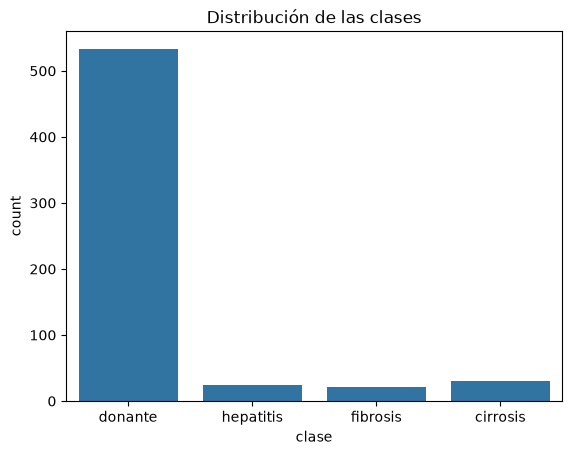

In [8]:
sns.countplot(data=df, x="clase", order=ORDEN)
plt.title("Distribución de las clases")
plt.show()

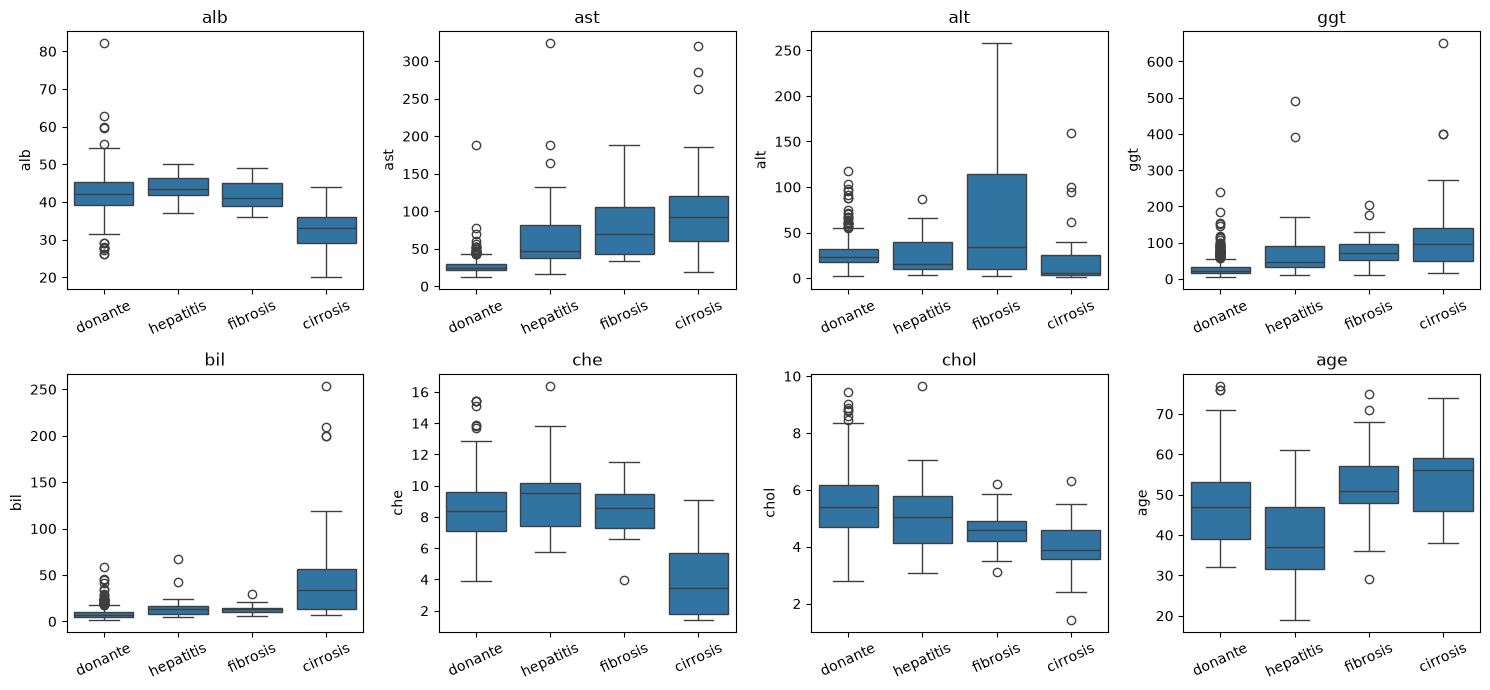

,ast,ggt,alb,che,bil
clase,,,,,
donante,24.8,21.4,42.2,8.4,6.9
hepatitis,47.2,45.6,43.5,9.5,13.0
fibrosis,70.0,72.2,41.0,8.6,13.0
cirrosis,92.9,96.4,33.0,3.4,34.0


In [9]:
fig, ejes = plt.subplots(2, 4, figsize=(15, 7))
for eje, variable in zip(ejes.ravel(), ["alb", "ast", "alt", "ggt", "bil", "che", "chol", "age"]):
    sns.boxplot(data=df, x="clase", y=variable, order=ORDEN, ax=eje)
    eje.set_title(variable)
    eje.set_xlabel("")
    eje.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
df.groupby("clase")[["ast", "ggt", "alb", "che", "bil"]].median().reindex(ORDEN).round(1)

Las enzimas AST y GGT **suben con la gravedad**. En la cirrosis bajan la albúmina y la colinesterasa y sube la bilirrubina. Todo esto es coherente con lo que se espera de la fisiología del hígado (Giannini et al., 2005). La hepatitis es la clase más difícil de separar de un donante, porque su laboratorio es casi normal salvo por las enzimas.

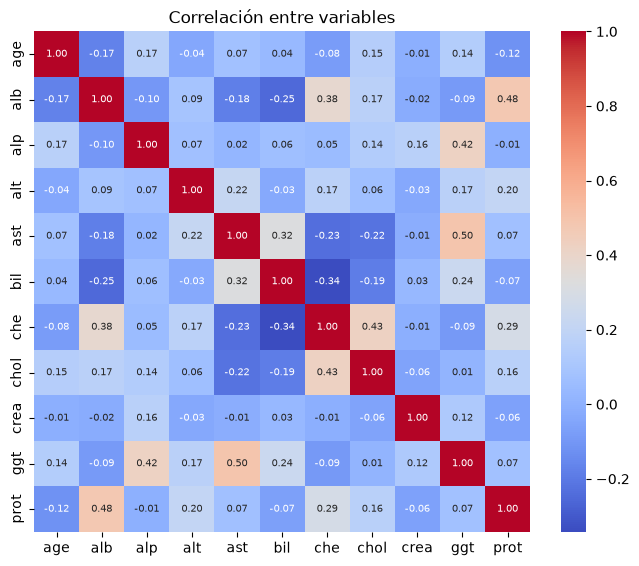

In [10]:
plt.figure(figsize=(8, 6.5))
sns.heatmap(df[["age"] + LABORATORIO].corr(), annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size": 7})
plt.title("Correlación entre variables")
plt.show()

AST, ALT y GGT están correlacionadas entre sí, es decir, aportan información parcialmente repetida.

---
# Sección 3: Ajuste del Modelo
---

## Modelo de Machine Learning

La división es estratificada. Con solo 21 a 30 casos por clase de enfermedad, cada uno cuenta.

In [11]:
NUMERICAS = ["age"] + LABORATORIO
VARIABLES = NUMERICAS   # edad y diez análisis; el sexo no aporta nada medible y es un dato sensible
train, test, y_train, y_test = train_test_split(df, df["clase"], test_size=0.2, stratify=df["clase"], random_state=SEMILLA)
print("Entrenamiento:", len(train), " Prueba:", len(test))
print("Casos por clase en la prueba:", y_test.value_counts().reindex(ORDEN).to_dict())

Entrenamiento: 486  Prueba: 122
Casos por clase en la prueba: {'donante': 107, 'hepatitis': 5, 'fibrosis': 4, 'cirrosis': 6}


### El ALP: artefacto o señal

Si el aporte del ALP viniera de sus vacíos, entonces (1) rellenar los vacíos con **valores observados al azar** lo haría desaparecer y (2) un **indicador de "ALP faltante"** lo reproduciría. Se prueba con un Random Forest y validación cruzada (solo con el entrenamiento).

In [12]:
def armar(estimador, variables=VARIABLES, escalar=True):
    categoricas = [v for v in variables if v == "sex"]
    numericas = [v for v in variables if v != "sex"]
    columnas = ColumnTransformer([
        ("num", Pipeline([("imputar", SimpleImputer(strategy="median"))] + ([("escala", StandardScaler())] if escalar else [])), numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categoricas),
    ])
    return Pipeline([("pre", columnas), ("modelo", estimador)])

validacion = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=SEMILLA)
bosque = dict(n_estimators=200, min_samples_leaf=2, max_depth=8, class_weight="balanced_subsample", random_state=SEMILLA, n_jobs=-1)

azar = train.copy()
vacios = azar["alp"].isna()
azar.loc[vacios, "alp"] = np.random.default_rng(SEMILLA).choice(train["alp"].dropna().to_numpy(), int(vacios.sum()))
sin_alp = [v for v in VARIABLES if v != "alp"]
casos = {
    "con ALP": (train, VARIABLES),
    "sin ALP": (train, sin_alp),
    "con los vacíos de ALP rellenados al azar": (azar, VARIABLES),
    "solo el indicador de ALP faltante (sin ALP)": (train, sin_alp + ["alp_faltante"]),
    "solo filas con ALP observada, con ALP": (train[train["alp"].notna()], VARIABLES),
    "solo filas con ALP observada, sin ALP": (train[train["alp"].notna()], sin_alp),
}
filas = {}
for nombre, (datos_cv, cols) in casos.items():
    r = cross_validate(armar(RandomForestClassifier(**bosque), cols, escalar=False), datos_cv[cols], datos_cv["clase"], cv=validacion, scoring="f1_macro")
    filas[nombre] = {"F1 macro cv": r["test_score"].mean(), "desviación": r["test_score"].std()}
pd.DataFrame(filas).T.round(3)

,F1 macro cv,desviación
con ALP,0.628,0.117
sin ALP,0.582,0.108
con los vacíos de ALP rellenados al azar,0.621,0.122
solo el indicador de ALP faltante (sin ALP),0.595,0.119
"solo filas con ALP observada, con ALP",0.681,0.102
"solo filas con ALP observada, sin ALP",0.575,0.096


La mejora se mantiene con el relleno aleatorio, el indicador solo aporta poco, y en las filas donde el ALP sí se observó la mejora es mayor. Es lo contrario de lo que pasaba con el `bmi` del modelo de ACV: **aquí el ALP aporta señal real**, no un artefacto. Se incluye, imputado con la mediana dentro del Pipeline.

> Analogía: dos pacientes con el mismo síntoma no se tratan igual solo porque un caso parezca "como el anterior". Primero se hace el examen. Aquí el examen mostró que el ALP sí informa, y que el `bmi` no.

### Candidatos

Se ponderan las clases para que las raras cuenten. Por eso los puntajes del modelo **no son probabilidades calibradas**.

In [13]:
def candidatos():
    return {
        "clase mayoritaria (línea base)": armar(DummyClassifier(strategy="most_frequent")),
        "regresión logística": armar(LogisticRegression(max_iter=5000, class_weight="balanced")),
        "k vecinos": armar(KNeighborsClassifier(n_neighbors=5, weights="distance")),
        "random forest": armar(RandomForestClassifier(**bosque), escalar=False),
    }

X_train, X_test = train[VARIABLES], test[VARIABLES]
filas = {}
for nombre, pipe in candidatos().items():
    r = cross_validate(pipe, X_train, y_train, cv=validacion, scoring={"f1": "f1_macro", "bal": "balanced_accuracy"})
    filas[nombre] = {"F1 macro cv": r["test_f1"].mean(), "desviación": r["test_f1"].std(), "exactitud balanceada cv": r["test_bal"].mean()}
comparacion = pd.DataFrame(filas).T.round(3)
comparacion

,F1 macro cv,desviación,exactitud balanceada cv
clase mayoritaria (línea base),0.234,0.000,0.250
regresión logística,0.595,0.072,0.662
k vecinos,0.547,0.093,0.511
random forest,0.628,0.117,0.600


La desviación entre particiones es grande (alrededor de 0.07 a 0.11) y las diferencias entre la regresión logística y el Random Forest son menores que eso. Se elige el de mayor F1 macro, pero la elección es casi un empate.

In [14]:
ganador = comparacion.drop("clase mayoritaria (línea base)")["F1 macro cv"].idxmax()
print("Modelo elegido:", ganador)
modelo = candidatos()[ganador].fit(X_train, y_train)

Modelo elegido: random forest


##### Evaluación en el conjunto de prueba

              precision    recall  f1-score   support

     donante      0.947     1.000     0.973       107
   hepatitis      1.000     0.200     0.333         5
    fibrosis      0.333     0.250     0.286         4
    cirrosis      0.800     0.667     0.727         6

    accuracy                          0.926       122
   macro avg      0.770     0.529     0.580       122
weighted avg      0.922     0.926     0.912       122



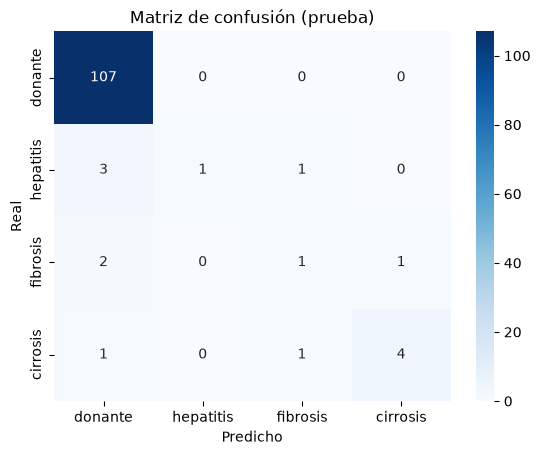

In [15]:
pred = modelo.predict(X_test)
print(classification_report(y_test, pred, labels=ORDEN, digits=3, zero_division=0))
matriz = confusion_matrix(y_test, pred, labels=ORDEN)
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", xticklabels=ORDEN, yticklabels=ORDEN)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión (prueba)")
plt.show()

In [16]:
def sensibilidad_y_especificidad(real, predicho):
    r, p = np.isin(np.asarray(real), ENFERMEDAD), np.isin(np.asarray(predicho), ENFERMEDAD)
    return {"sensibilidad": round(float(p[r].mean()), 3), "especificidad": round(float((~p[~r]).mean()), 3)}

print("Enfermedad contra donante (prueba):", sensibilidad_y_especificidad(y_test, pred))
f1_macro_de = lambda y, p: float(f1_score(y, p, labels=ORDEN, average="macro", zero_division=0))

def intervalo_bootstrap(y, p, funcion, remuestreos=1000, semilla=42):
    rng = np.random.default_rng(semilla)
    valores = []
    while len(valores) < remuestreos:
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) > 1:
            valores.append(funcion(y[i], p[i]))
    return [round(float(np.percentile(valores, 2.5)), 4), round(float(np.percentile(valores, 97.5)), 4)]

print("F1 macro de prueba: %.3f" % f1_macro_de(y_test, pred))
print("IC 95 % del F1 macro:", intervalo_bootstrap(np.asarray(y_test), pred, f1_macro_de))

Enfermedad contra donante (prueba): {'sensibilidad': 0.6, 'especificidad': 1.0}
F1 macro de prueba: 0.580


IC 95 % del F1 macro: [0.3682, 0.7525]


La exactitud es alta, pero engaña: el 88 % son donantes. El intervalo del F1 macro es muy amplio, porque en la prueba hay solo 4 a 6 casos de cada enfermedad. Una sola persona cambia el resultado de forma importante.

### Predicciones fuera de muestra del entrenamiento

Para tener estimaciones por clase menos ruidosas se usan las predicciones de validación cruzada sobre las 486 personas del entrenamiento.

In [17]:
oof = cross_val_predict(candidatos()[ganador], X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=SEMILLA))
informe = pd.DataFrame(classification_report(y_train, oof, labels=ORDEN, output_dict=True, zero_division=0)).T.loc[ORDEN].round(3)
print("F1 macro fuera de muestra: %.3f" % f1_macro_de(y_train, oof))
print("Enfermedad contra donante (fuera de muestra):", sensibilidad_y_especificidad(y_train, oof))
informe

F1 macro fuera de muestra: 0.661
Enfermedad contra donante (fuera de muestra): {'sensibilidad': 0.733, 'especificidad': 0.998}


,precision,recall,f1-score,support
donante,0.964,0.998,0.980,426.0
hepatitis,0.583,0.368,0.452,19.0
fibrosis,0.500,0.353,0.414,17.0
cirrosis,0.857,0.750,0.800,24.0


La cirrosis se reconoce bien. **La hepatitis y la fibrosis se detectan mal**, algo esperable porque sus análisis de laboratorio se parecen a los de un donante.

La regresión logística, casi empatada en validación cruzada, tiene otro compromiso entre sensibilidad y especificidad. Vale la pena mirarlo:

In [18]:
oof_lr = cross_val_predict(candidatos()["regresión logística"], X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=SEMILLA))
print("Regresión logística, F1 macro fuera de muestra: %.3f" % f1_macro_de(y_train, oof_lr))
print("Enfermedad contra donante:", sensibilidad_y_especificidad(y_train, oof_lr))

Regresión logística, F1 macro fuera de muestra: 0.626
Enfermedad contra donante: {'sensibilidad': 0.917, 'especificidad': 0.927}


La regresión logística detecta mucho más la enfermedad (mayor sensibilidad), a costa de confundir más donantes con enfermos (menor especificidad). Elegir entre las dos es decidir qué error importa más.

### Predicción para una persona nueva

In [19]:
persona = pd.DataFrame([{"age": 47, "alb": 42.0, "alp": 66.0, "alt": 23.0, "ast": 25.0, "bil": 7.3, "che": 8.3, "chol": 5.3, "crea": 77.0, "ggt": 23.0, "prot": 72.0}])
puntajes = dict(zip(modelo.classes_, modelo.predict_proba(persona[VARIABLES])[0].round(3)))
print("Clase más probable:", modelo.predict(persona[VARIABLES])[0])
print({k: float(v) for k, v in puntajes.items()})

Clase más probable: donante
{'cirrosis': 0.0, 'donante': 1.0, 'fibrosis': 0.0, 'hepatitis': 0.0}


---
# Conclusiones
---

## Resultados

Con la edad y diez análisis de sangre se distingue bien a los donantes de los pacientes y se reconoce la cirrosis, pero **la hepatitis y la fibrosis se detectan mal**. Las enzimas AST y GGT, la bilirrubina, la albúmina, la colinesterasa y el ALP son las señales más claras.

Hay tres hallazgos metodológicos. Primero, ante un valor faltante sospechoso hay que distinguir artefacto de señal con un experimento: aquí el ALP resultó ser señal. Segundo, la elección entre dos modelos casi empatados es en realidad un compromiso entre sensibilidad y especificidad que debe declararse. Tercero, con 4 a 6 casos por clase en la prueba el resultado depende mucho de la partición.

Limitaciones: **no es un diagnóstico**. Hay solo 21 a 30 casos por clase de enfermedad. Donantes y pacientes vienen de poblaciones distintas (ningún donante tiene menos de 32 años), así que el modelo puede aprender la población y no la enfermedad, y no hay validación externa. Los puntajes no son probabilidades calibradas. Las unidades de los análisis no vienen documentadas en la fuente.

### Referencias

> Giannini, E. G., Testa, R., & Savarino, V. (2005). Liver enzyme alteration: a guide for clinicians. *Canadian Medical Association Journal*, 172(3), 367-379.
> Hoffmann, G., Bietenbeck, A., Lichtinghagen, R., & Klawonn, F. (2018). Using machine learning techniques to generate laboratory diagnostic pathways: a case study. *Journal of Laboratory and Precision Medicine*, 3.
> Lichtinghagen, R., Pietsch, D., Bantel, H., Manns, M. P., Brand, K., & Bahr, M. J. (2013). The Enhanced Liver Fibrosis (ELF) score: Normal values, influence factors and proposed cut-off values. *Journal of Hepatology*, 59(2), 236-242.
> Manns, M. P., Buti, M., Gane, E., et al. (2017). Hepatitis C virus infection. *Nature Reviews Disease Primers*, 3, 17006.